# Milestone 2 - Skiing Conditions and Comfort
Claudia, Paige, Paula

## 1. Design the Threat Index

### Design Factors

#### What is the focus for the threat index?
We are focusing on an application-specific impact for our threat index where weather impacts skiing conditions.This threat index focus is more application rather than a specific weather phenomenom because we aren't just looking at a single winter storm or other phenomenom, we're looking at how specific weather conditions combined make for optimal days to enjoy skiing in the Northeast. While many indices focus on the severity of a storm, this index focuses on recreational viability. In the Northeast, conditions are notorious for being either really harsh and volatile with ice to being extremely warm and slushy slow within just a couple of days. This index synthesizes Numerical Weather Prediction (NWP data) which accounts for both the quality of conditions and the physical comfort of the skier. 

#### What is our target audience?
Our target audience would be the general public who enjoy the outdoor sport of skiing/snowboarding. Essentially, any person who wants to head up to a mountain in the Northeast that offers the sport, and needs to see if all factors considered would be an enjoyable day worth skiing. This demographic is sensitive to the safety and enjoyment of the skier by avoiding frostbite, dangerous wind chills, melting days, or rainy days. In addition, our index places high value on the amount of snow in order to maximize skiing enjoyability, as this sport can be expensive. Lastly, our index makes sure to take into account the trail visibility by weighting the cloud cover in order to find which area will have the best possible ski conditions. Having high cloud cover can make it difficult to see trails, so this safety precaution is built into our programming.


#### What is the appropriate scale or range for the index?
Our scale would be from 0-100. Any area with zeroes based off our colorbars would mean conditions are not at all optimal for skiing posing safety risks by extreme cold/temperatures above freezing or total snowmelt/rain. Any area with one-hundred would mean perfect conditions and all variables align together. Specifically, our audience would be paying attention to areas where the scale ranges from 80-100, because this would indicate fresh snow, light winds, and temperatures cold enough for snow to remain without it being too cold to ski for a prolonged period of time. Anywhere in the 50-70 range is safe and skiiable but may involve icy patches on the mountains or high cloud cover. Examples of sub-optimal conditions would appear in the 1-49 range where thin snow cover, rain, and/or high winds might affect lift operations and skiing enjoyability. 

#### NWP model variables
The variables we'll be working with are, temperature(2m), total precipitation, categorial snow, wind speed, and total cloud cover. Below, to create a productive function, we weigh these variables based on the impact to user experience. 

#### Group Member Contribution
In the process on designing and completing milestone 2, Paige, Claudia, and Paula all worked on the project together in class with equal contributions. There are no specific sections notated as being done by one specific person for this reason.

### Developing a formula: Threat Index Example: Skiing Index
- Range: 0 to 100
- 0 = no skiing (mountain is closed)
- 100 = best possible

Best possible conditions:
- temperature between 20 - 32 F
- less than 50% cloud cover
- wind speed less than 50 mph
- total snow precipitation from 1-6 in 

Weighting:
- temperature: 40%
- clouds: 10%
- wind: 20%
- total snow precipitation: 30%

Temperature contribution:
- 0 when T > 50 F
- 1 when 20 <= T <= 32
- 0 when T < 0
- function slope from 0 - 20 and 32 - 50


#### Function for temp distribution:

y = 0 {x < 0}

y = (1 - ((20 - x)/20)^2) {0 <= x < 20}

y = 1 {20 <= x <= 32}

y = (1 - ((x - 32)/18)^2) {32 < x <= 50}

y = 0 {x > 50}

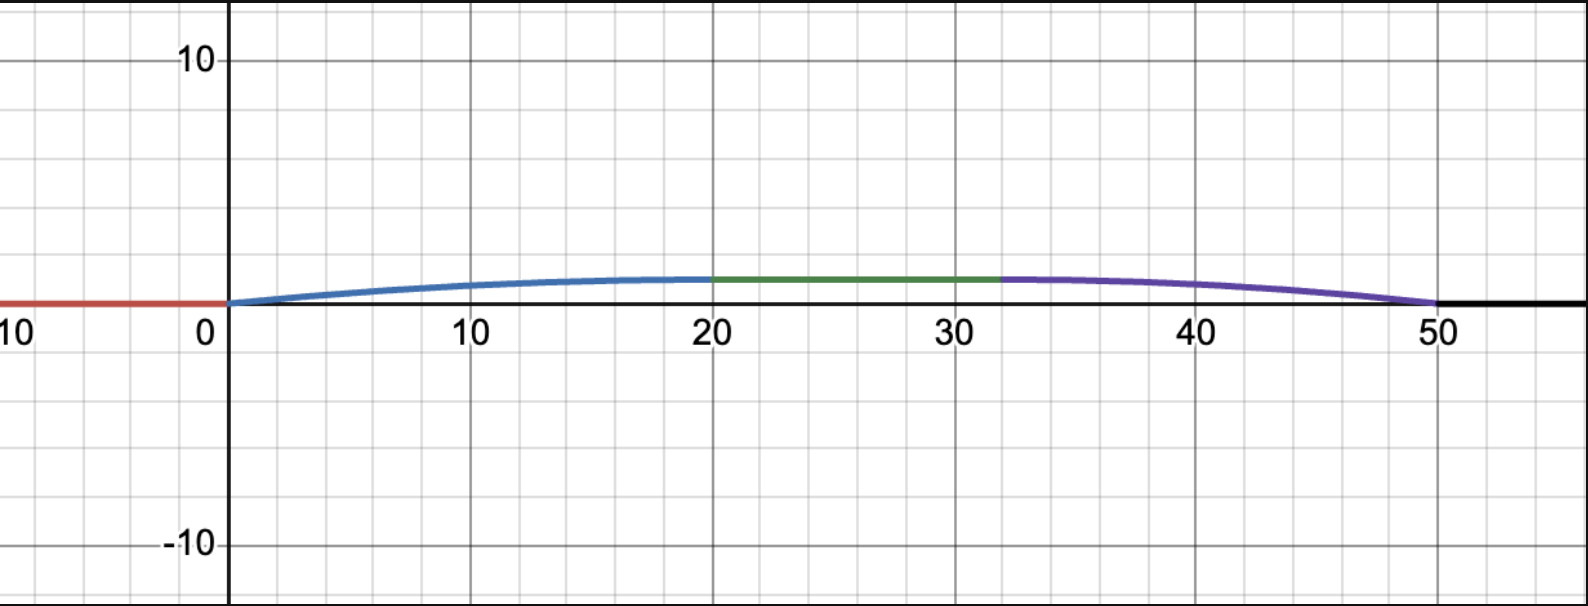

#### Function for cloud cover:

y = (0.01x + 0.5){0 ≤ x ≤ 50}

y = (-0.01x + 1.5){50 ≤ x ≤ 100}

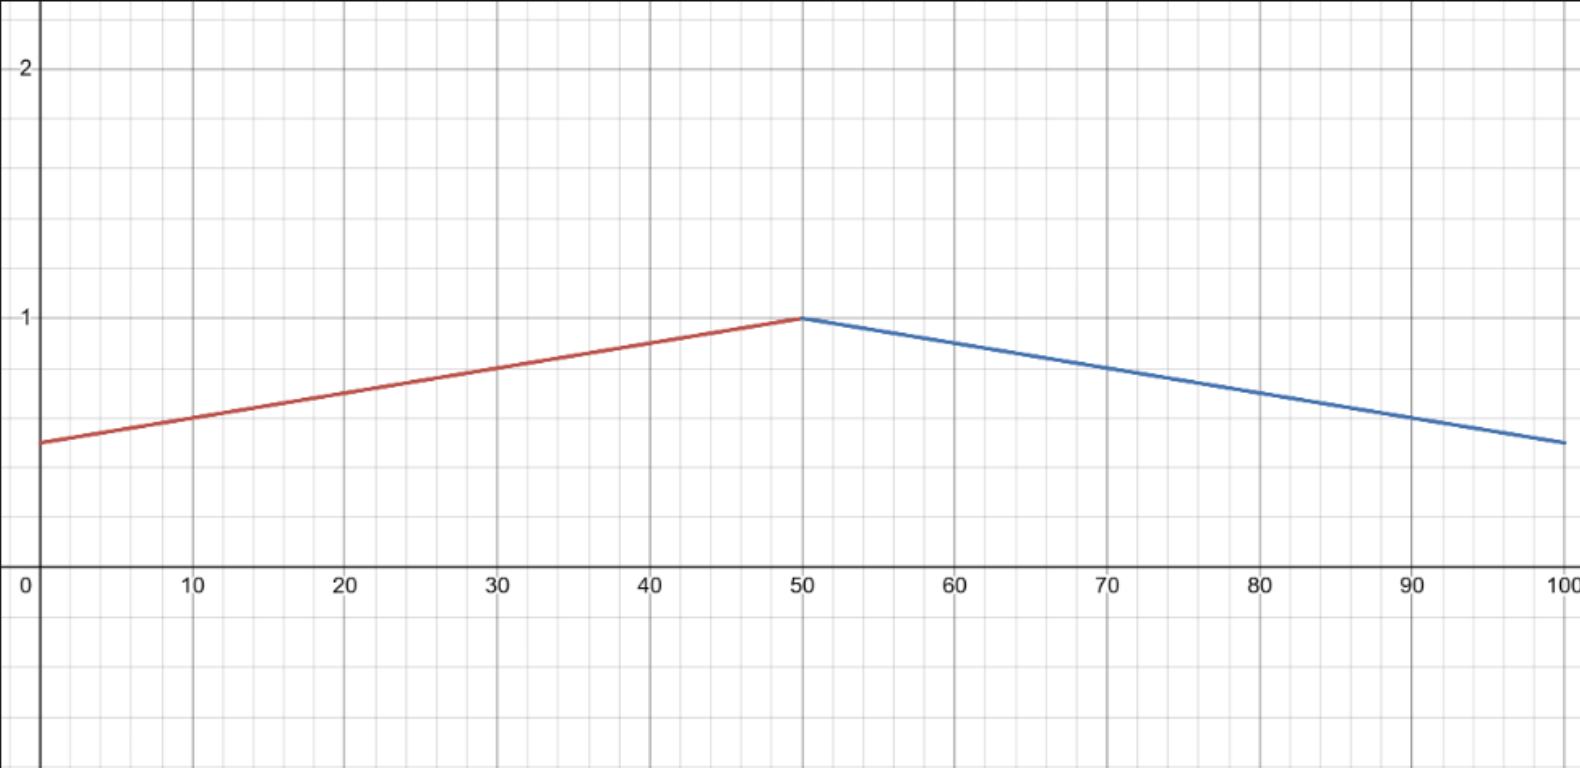 

#### Function for wind speed: 

y = (-1/50)x -1 {0 < x < 50}

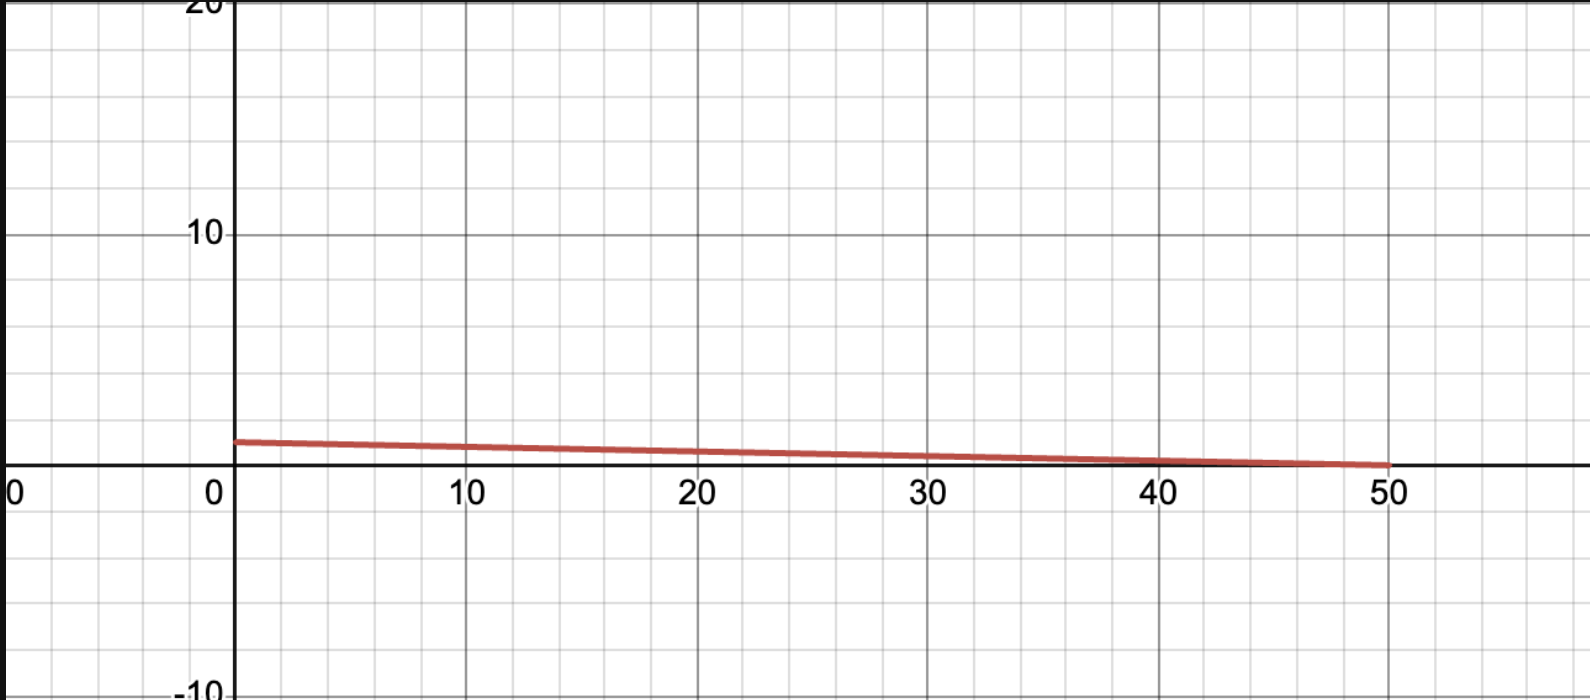

#### Function for snow depth:

y = 1 {x > 6}

y = ((1/6)(x)) {0 <= x <= 6}

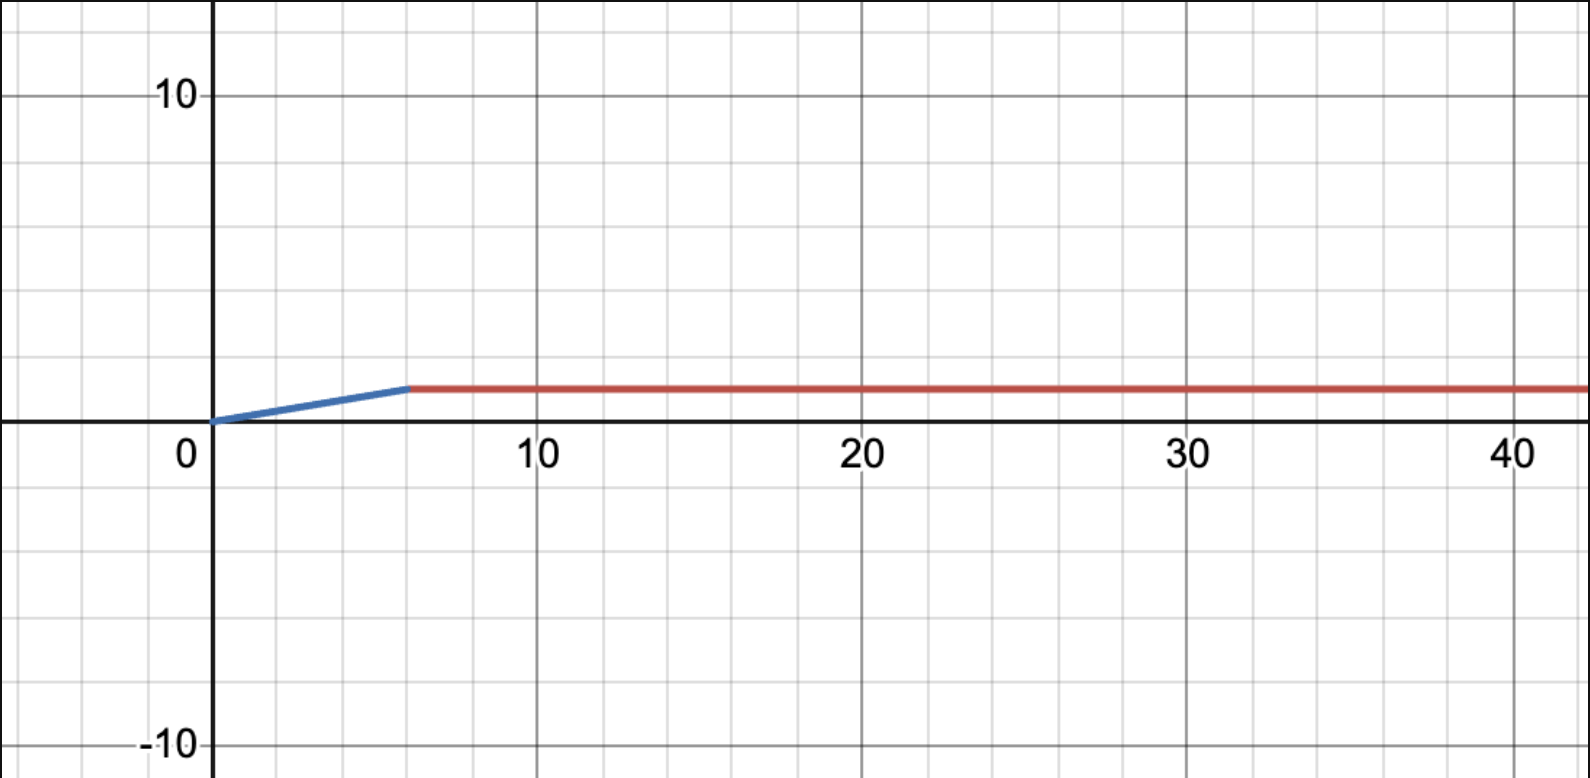 


### Imports

In [1]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs, cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import xarray as xr
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Data Code

In [2]:
ds = xr.open_dataset('gfs.nc')

sh: 1: getfattr: not found


In [3]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:            (valid_time: 40, latitude: 81, longitude: 81)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 320B 2026-02-22 ... 2026-0...
  * latitude           (latitude) float64 648B 55.0 54.75 54.5 ... 35.25 35.0
  * longitude          (longitude) float64 648B 280.0 280.2 ... 299.8 300.0
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 320B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    atmosphere         float64 8B ...
Data variables:
    sde                (valid_time, latitude, longitude) float32 1MB ...
    t2m                (valid_time, latitude, longitude) float32 1MB ...
    tp                 (valid_time, latitude, longitude) float32 1MB ...
    tcc                (valid_time, latitude, longitude) float32 1MB ...
    u10                (valid_time, latitude, longitude) float32 1MB ...
    v10                (valid_time, latitude, longitude) float32 1MB ...
    csnow              (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T17:15 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
# Selecting a time in the data set to work with
chosen_hour = 6
s_ds = ds.isel(valid_time = chosen_hour)   

In [5]:
# Selecting the northeast of the united states: 
ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))  

#Extracting variables:
t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit

tcc = ds_ne['tcc'].values #%

u = ds_ne['u10'].values * 2.23694 
v = ds_ne['v10'].values * 2.23694 
wind = np.sqrt(u**2 + v**2) #mph

sde = ds_ne['sde'].values * 100 #Cm

csnow = ds_ne['csnow'].values #catagorial snow

tp = ds_ne['tp'].values * 2.54 #in inches and changed to snow from liquid using ratio 10:1

lat = ds_ne.latitude.values
lon = ds_ne.longitude.values

In [6]:
# Extracting values for 6 hr interval for the total snow precip. 
tp_chosenhr= ds.tp.isel(valid_time= chosen_hour).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_prevhr = ds.tp.isel(valid_time= chosen_hour - 1).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_interval = tp_chosenhr - tp_prevhr
tp_interval = tp_interval * 0.03937 * 10 #in inches and changed to snow from liquid using ratio 10:1

#### 2 Meter Temperature

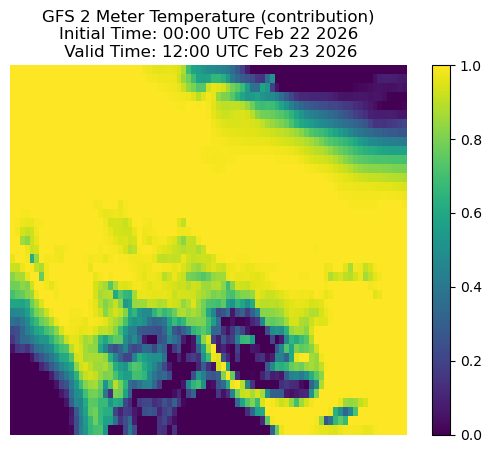

In [7]:
# Contribution: 
t2m_contribution = np.zeros_like(t2m_f)
#getting valid time and initial time from the dataset
valid_time = datetime.strptime(str(ds.valid_time.values[chosen_hour])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the plot
initial_time = datetime.strptime(str(ds.valid_time.values[0])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y")

# 0 <= T < 20 : increase from 0 to 1
mask = (t2m_f >= 0) & (t2m_f < 20)
t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)

# 20 <= T <= 32 : contribution = 1
mask = (t2m_f >= 20) & (t2m_f <= 32)
t2m_contribution[mask] = 1.0

# 32 < T < 50 : decrease from 1 to 0.5
mask = (t2m_f > 32) & (t2m_f < 50)
t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)

# T >- 50 : contribution = 0
mask = t2m_f >= 50
t2m_contribution[mask] = 0


# Plotting: 
plt.pcolormesh(lon, lat, np.flipud(t2m_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS 2 Meter Temperature (contribution)\nInitial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Total Cloud Cover

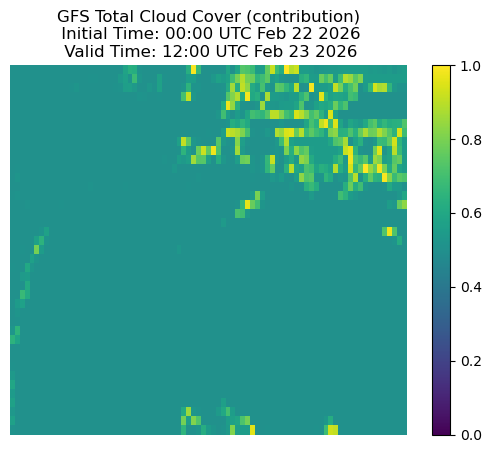

In [8]:
# Contribution:
tcc_contribution = np.zeros_like(tcc)

# 0 <= tcc <= 50 : linear increase from 0% to 50%
mask = (tcc >= 0) & (tcc <= 50)
tcc_contribution[mask] = (0.01)*(tcc[mask]) + 0.5

# 50 < tcc <= 100 : linear decrease from 50% tp 100%
mask = (tcc > 50)
tcc_contribution[mask] = (-0.01)*(tcc[mask]) + 1.5

# Plotting:
plt.pcolormesh(np.flipud(tcc_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Total Cloud Cover (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Wind

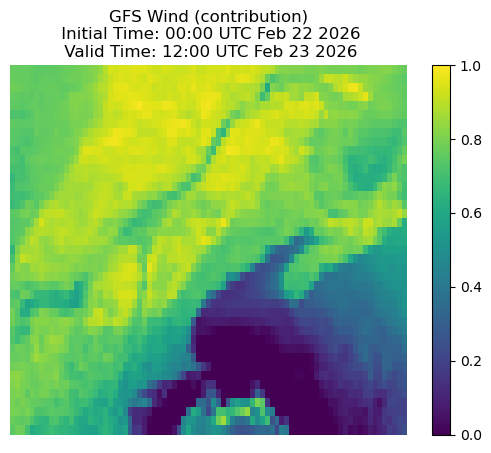

In [9]:
# Contribution:
wind_contribution = np.zeros_like(wind)

# 0 <= T <= 50 : increase
mask = (wind >= 0) & (wind <= 50)
wind_contribution[mask] = ((-1/50)*(wind[mask])) + 1

#Plotting: 
plt.pcolormesh(np.flipud(wind_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Wind (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Total Snow Precipitation

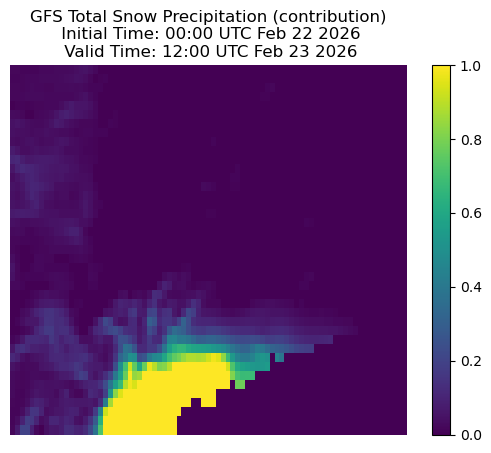

In [10]:
#Choosing Where it's Snowing and not Raining
tp_snow_only = np.where(csnow == 1, tp_interval, 0)
tp_contribution = np.zeros_like(tp_snow_only)

#Masking for total precip 
mask = (tp_snow_only >= 0) & (tp_snow_only <= 6)
tp_contribution[mask] = ((1/6)*(tp_snow_only[mask]))
mask = (tp_snow_only > 6)
tp_contribution[mask] = 1

# plotting where it is snowing
plt.pcolormesh(np.flipud(tp_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Total Snow Precipitation (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Final Equation

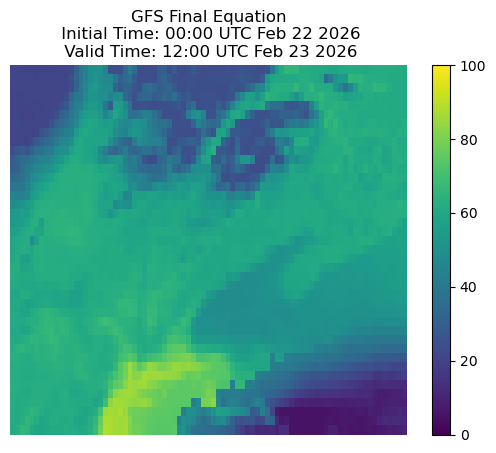

In [11]:
#equation for threat index with our four variables' contributions
PUI = (t2m_contribution*0.4 + tcc_contribution*0.1 + wind_contribution*0.2 + tp_contribution*0.3)*100

# Plotting the Final Equation (threat index): 
plt.pcolormesh(np.flipud(PUI), vmin = 0, vmax = 100)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Final Equation\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

### Brainstorming
#### Reasoning for choosing the variables: 
- We firstly chose temperature(t2m) as it has a large impact on the quality of the skiing as well as the comfort of the skier. Temperatures that are too low would be uncomfortable to ski in and temperatures that are too high would cause snow melt which results in bad skiing conditions.
-  We chose cloud cover (tcc) because having high cloud cover could cause decreased visibility on trails, which is unsafe for skiers.
-  We chose wind becuase high winds could cause unsafe conditions on the mountains and result in ski lifts being closed, which would not be favorable for the ideal skiing day.
-  We chose snow precipitaton because having a good amount of snow while skiing not only makes it more enjoyable to ski, but it is also safer as the risk of ice, rocks, and branches on trails is decreased.

All of these variables together make up our ideal skiing conditions index.

#### Why this index would be useful to our audience:
This index would be useful for our audience becuase it would provide a platform for skiers to see where skiing is ideal. This is not only making the most out of the money they are investing in skiing, but it also ensures safe skiing conditions. These are all concerns people may have when skiing, so this index could aleviate that anxiety of having to choose an area/resort to ski in by providing a clear picture of what area is ideal for skiing.

#### How the formula works and why it makes sense:
The formula works by taking each weather variable and combining them into one overall score that represents how good the skiing conditions are. Each factor (temperature, cloud cover, wind, and snow) is given a weight based on how important it is for skiing conditions and skier safety. This formula makes sense because it puts the highest weight on the two most important factors for skiing (temperature and snowfall) and the rest of it is weighted on comfortability factors (wind and cloud cover). This reflects how the average skier would rank importance of different weather conditions for skiing enjoyability.

#### How each variable is weighted or combined:
The weighting for each variable can be seen above in the formula. It is as followed:
Temperature counting as 40%, clouds 10%, wind 20% and snow 30%. 
- Temperature is given the greatest weight because it has the most significant impact on skiing conditions. Cloud cover is assigned a smaller weight, as skiing can remain enjoyable under most sky conditions, though it is most comfortable when partly cloudy. 
- Wind accounts for 20%, since stronger winds can reduce comfort and impact the safety of ski lifts. 
- Snow is weighted at 30%, as both active snowfall and existing snow cover are essential for ideal skiing conditions. 
- In order to get the snowfall variable,the variables catagorial snow and total preciptation were combined. Firstly, we found the times where it was snowing from the categorial snow variable and then overlayed that across the total precipiation variable. Then we were able to get the precipiation totals just from the areas where snowfall was reported. Finally, these precipitation values were then converted using the snow liquid ratio to reflect how much snowfall was received.


## 2. Implementing the Algorithm

## Choosing an efficient time step

In [12]:
chosen_ts = [1,3,5,7,9,11]

## Defining a function

In [13]:
#making def to accept xrray with our variables and then calculating the threat index based on our previous PUI formula
def threat_index(ds, chosen_ts):
    s_ds = ds.isel(valid_time = chosen_ts) 
    
    ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))   #selecting the northeast of the united states

    t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit
    tcc = ds_ne['tcc'].values #getting the percentage
    u = ds_ne['u10'].values * 2.23694 
    v = ds_ne['v10'].values * 2.23694 
    wind = np.sqrt(u**2 + v**2) #converting to mph
    csnow= ds_ne['csnow'].values
    tp_chosenhr= ds.tp.isel(valid_time= chosen_ts).values
    tp_prevhr = ds.tp.isel(valid_time= chosen_ts - 1).values
    tp_interval = tp_chosenhr - tp_prevhr #getting the total snow for each time interval and not the total accumalation over time
    
    sde = ds_ne['sde'].values * 100 #changing into Cm
    
    #2 Meter Temperature
    t2m_contribution = np.zeros_like(t2m_f)
    # 0 <= T < 20 : increase from 0 to 1
    mask = (t2m_f >= 0) & (t2m_f < 20)
    t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)
    # 20 <= T <= 32 : contribution = 1
    mask = (t2m_f >= 20) & (t2m_f <= 32)
    t2m_contribution[mask] = 1.0
    # 32 < T < 50 : decrease from 1 to 0.5
    mask = (t2m_f > 32) & (t2m_f < 50)
    t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)
    # T >- 50 : contribution = 0
    mask = t2m_f >= 50
    t2m_contribution[mask] = 0
   

    #Total Cloud Cover
    tcc_contribution = np.zeros_like(tcc)
    # 0 <= tcc <= 50 : linear increase from 0% to 50%
    mask = (tcc >= 0) & (tcc <= 50)
    tcc_contribution[mask] = (0.01)*(tcc[mask]) + 0.5
    # 50 < tcc <= 100 : linear decrease from 50% to 100%
    mask = (tcc > 50)
    tcc_contribution[mask] = (-0.01)*(tcc[mask]) + 1.5
    

    #Wind
    wind_contribution = np.zeros_like(wind)
    # 0 <= T <= 50 : increase
    mask = (wind >= 0) & (wind <= 50)
    wind_contribution[mask] = ((-1/50)*(wind[mask])) + 1
    
    
    #total snow precip 
    tp_chosenhr= ds.tp.isel(valid_time= chosen_ts).sel(latitude = slice(50,40), longitude = slice(280, 300)).values #getting chosen hrs for northeast
    tp_prevhr = ds.tp.isel(valid_time= chosen_ts - 1).sel(latitude = slice(50,40), longitude = slice(280, 300)).values  #getting chosen hrs for northeast
    tp_interval = tp_chosenhr - tp_prevhr
    tp_interval = tp_interval * 0.03937 * 10 #in inches and changed to snow from liquid using ratio 10:1
    tp_snow_only = np.where(csnow == 1, tp_interval, 0) #getting total precip values only where there is snow
    tp_contribution = np.zeros_like(tp_snow_only)
    mask = (tp_snow_only >= 0) & (tp_snow_only <= 6) #masking for values between 0 to 6 inches
    tp_contribution[mask] = ((1/6)*(tp_snow_only[mask])) #linear increase from 0% to 100% for snow
    mask = (tp_snow_only > 6)
    tp_contribution[mask] = 1

    #final equation
    PUI = (t2m_contribution*0.4 + tcc_contribution*0.1 + wind_contribution*0.2 + tp_contribution*0.3)*100
   
    
    return PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution #returning the array containing values

    #have return index have threat index and input varibles

## 3. Visualizing the Output

## Creating multi-panel plot (using sublots)  

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


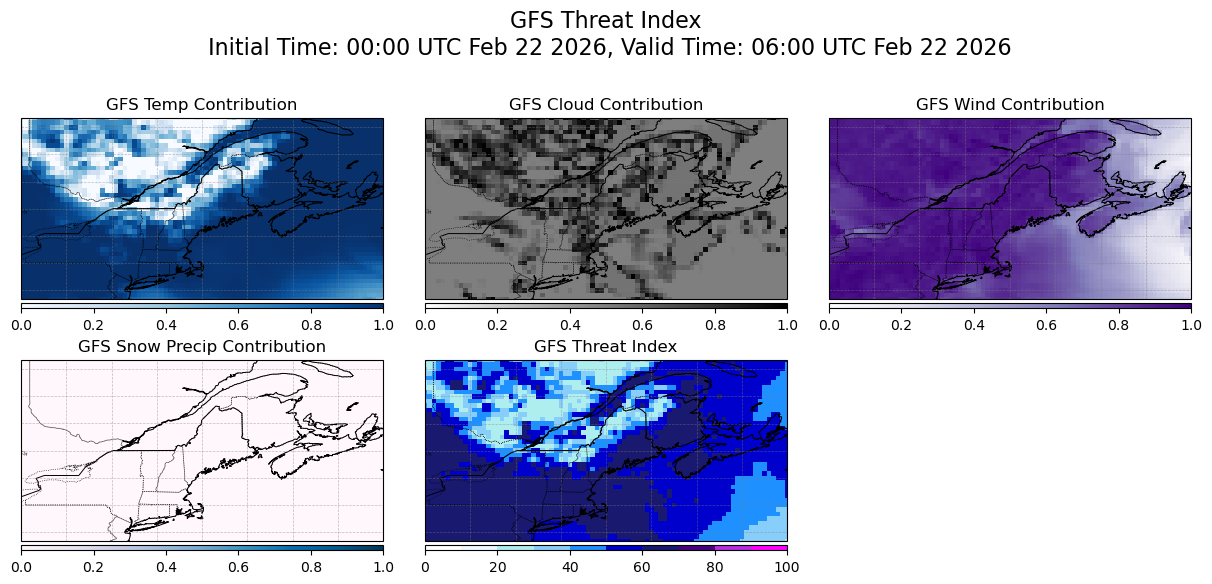

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


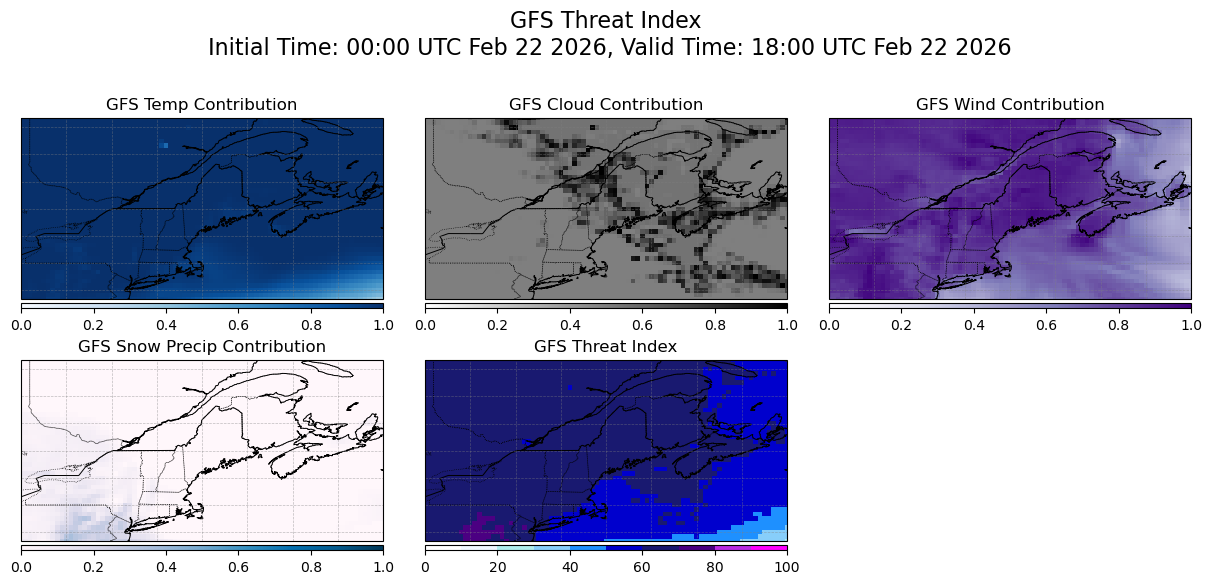

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


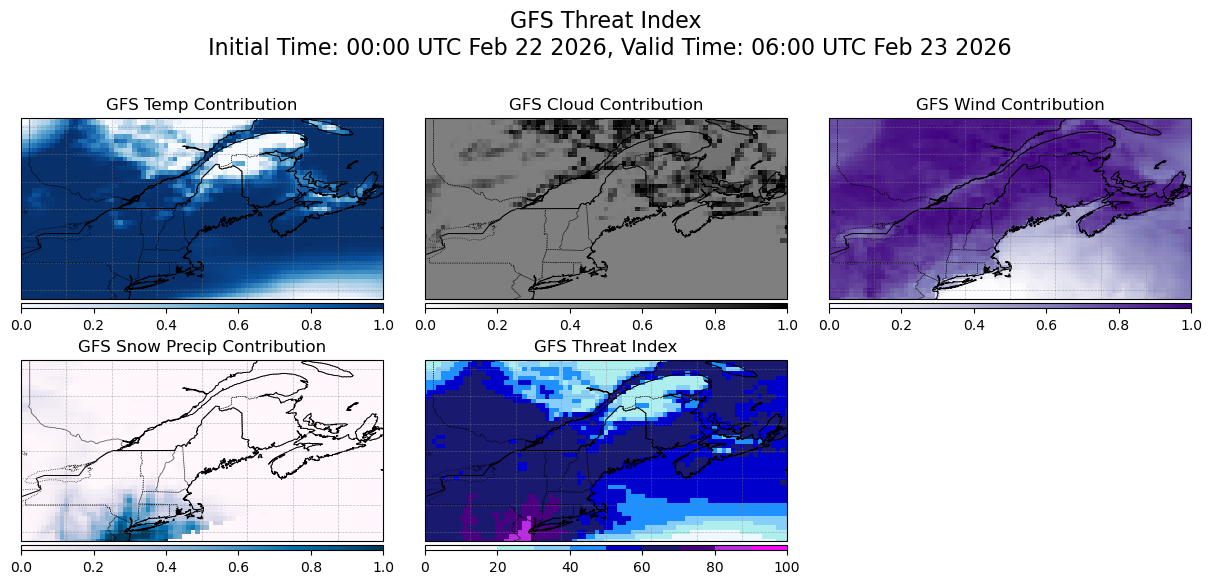

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


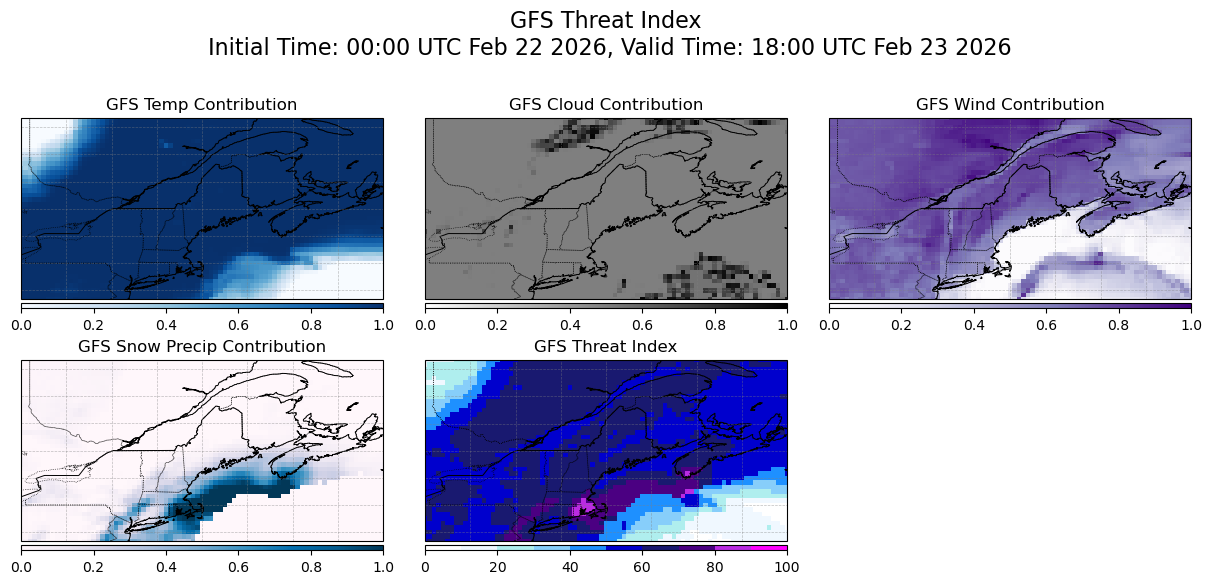

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


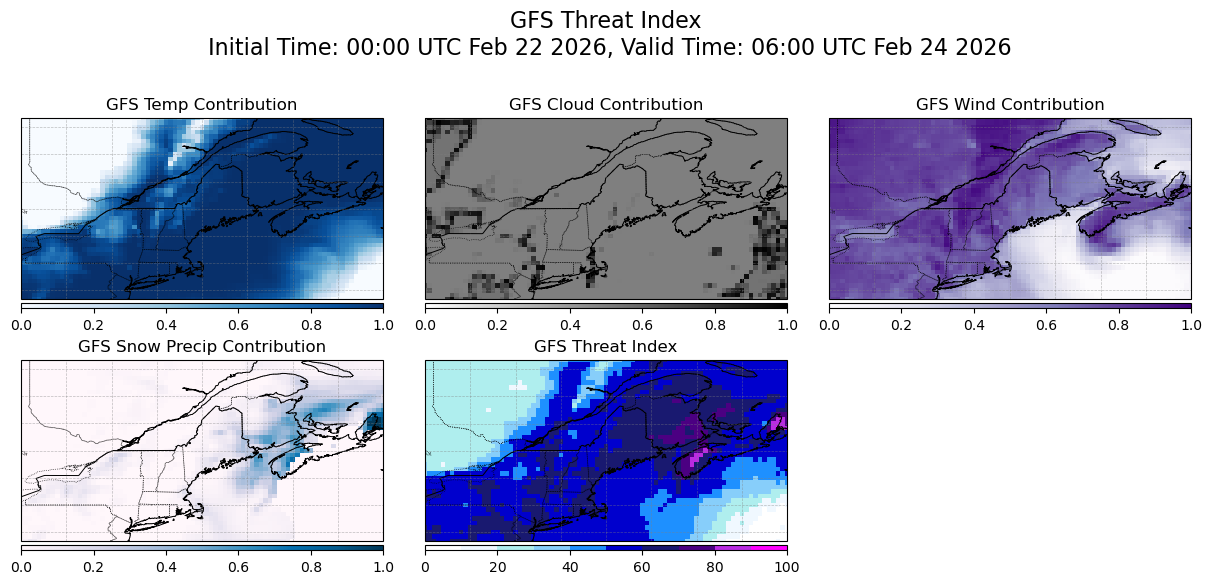

/tmp/ipykernel_1143762/856771719.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad=3)


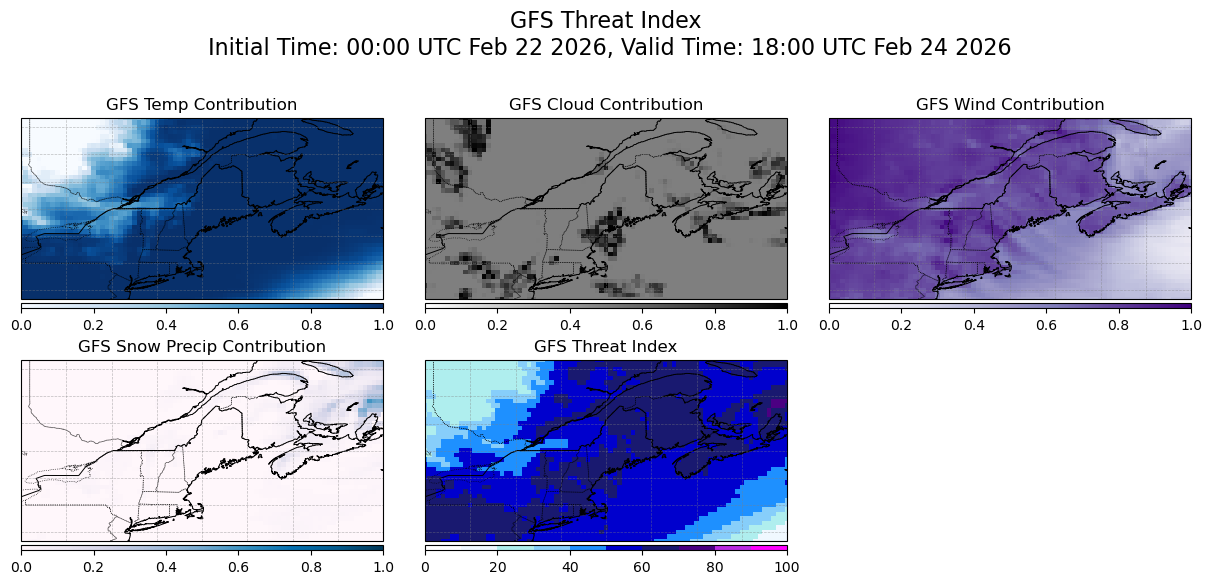

In [14]:
#getting initial time for contributions and threat index
initial_time = pd.to_datetime(ds.valid_time.values[0]).strftime("%H:%M UTC %b %d %Y")

#creating custom color range
colorbar_range = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
colorbar_custom = [
        '#ffffff',       # white
        '#f0f8ff',       # aliceblue
        '#afeeee',       # paleturquoise
        '#87cefa',       # lightskyblue
        '#1e90ff',       # dodgerblue
        '#0000cd',       # mediumblue
        '#191970',       # midnightblue
        '#4b0082',       # indigo
        '#ba2be2',       # blueviolet
        '#ff00ff'        # magenta
       ]
colorbar_cmap=mcolors.ListedColormap(colorbar_custom)

def basemap():
    fig = plt.figure(figsize = (12,6))
    axs = fig.subplots(nrows = 2, ncols = 3, subplot_kw = {'projection': ccrs.PlateCarree()})
    for ax in axs.flatten():
        ax.set_extent([-80,-60,40,50], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth = 0.7)
        ax.add_feature(cfeature.STATES, linestyle=':', linewidth = 0.5)
        ax.add_feature(cfeature.BORDERS, linewidth = 0.7)
    
        gridlines = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 0.5, color = 'gray', alpha = 0.5, linestyle = '--')

        #removing the extra '6th' axes that we do not need
        axs[1,2].set_visible(False)  

    return fig, axs

for t in chosen_ts: #Generating plot for 6 different time steps from our model run
    lat = ds_ne.latitude.values
    lon = ds_ne.longitude.values
    PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution = threat_index(ds, t)
    time_str = str(ds.valid_time.values[t])
    valid_time = datetime.strptime(time_str[:19], "%Y-%m-%dT%H:%M:%S").strftime("%H:%M UTC %b %d %Y")
    initial_time = datetime.strptime(str(ds.valid_time.values[0])[:19], "%Y-%m-%dT%H:%M:%S").strftime("%H:%M UTC %b %d %Y")

    
    fig, axs = basemap()
    #Plots 1-4: plots of each of the input parameters 
    ax=axs[0,0]
    plot1 = axs[0,0].pcolormesh(lon, lat, t2m_contribution , transform = ccrs.PlateCarree(), cmap='Blues',  vmin = 0, vmax = 1)
    axins = inset_axes(ax, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax.transAxes, borderpad = 0)
    plt.colorbar(plot1, cax = axins, orientation = 'horizontal') 
    axs[0,0].set_title("GFS Temp Contribution") #Plot Temp Contribution
    
    ax2=axs[0,1]
    plot2 = axs[0,1].pcolormesh(lon, lat, tcc_contribution , transform = ccrs.PlateCarree(), cmap='binary',  vmin = 0, vmax = 1)
    axins = inset_axes(ax2, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax2.transAxes, borderpad = 0)
    plt.colorbar(plot2, cax = axins, orientation = 'horizontal') 
    axs[0,1].set_title("GFS Cloud Contribution") #Plot Cloud Contribution

    ax3 = axs[0,2]
    plot3 = axs[0,2].pcolormesh(lon, lat, wind_contribution , transform = ccrs.PlateCarree(), cmap='Purples',  vmin = 0, vmax = 1)
    axins = inset_axes(ax3, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax3.transAxes, borderpad = 0)
    plt.colorbar(plot3, cax = axins, orientation = 'horizontal')
    axs[0,2].set_title("GFS Wind Contribution") #Plot Wind Contribution

    ax4 = axs[1,0]
    plot4 = axs[1,0].pcolormesh(lon, lat, tp_contribution , transform = ccrs.PlateCarree(), cmap='PuBu',  vmin =0, vmax = 1)
    axins = inset_axes(ax4, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax4.transAxes, borderpad = 0)
    plt.colorbar(plot4, cax = axins, orientation = 'horizontal')
    axs[1,0].set_title("GFS Snow Precip Contribution") #Plot Snow Precip Contribution

    #plotting our threat index with custom color range
    ax5 = axs[1,1]
    plot5 = axs[1,1].pcolormesh(lon, lat, PUI , transform = ccrs.PlateCarree(), cmap=colorbar_cmap,  vmin = 0, vmax = 100)
    axins = inset_axes(ax5, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax5.transAxes, borderpad = 0)
    plt.colorbar(plot5, cax = axins, orientation = 'horizontal')
    axs[1,1].set_title("GFS Threat Index") #Plot of the threat index
    
   
    #saving each seperate time step with a changing initial time and valid time 
    fig.suptitle(f"GFS Threat Index\n Initial Time: {initial_time}, Valid Time: {valid_time}", fontsize=16) 
    fig.tight_layout(w_pad=3) 
    plt.show()



In [15]:
#naming the variable for threat index
PUI, t2m_contribution, tcc_contribution, wind_contribution, sde_contribution = threat_index(ds, 6)

## 4. Test the Algorithm on Additional Events

## Opening Two Datasets

In [16]:
#High-end Case: January 25, 2026 
ds_high = xr.open_dataset("gfs.nc_high")

#Low-end Case: January 29, 2025
ds_low = xr.open_dataset("gfs.nc_low")

sh: 1: getfattr: not found
sh: 1: getfattr: not found


## Extracting same variables for these datasets and running it through threat index:

### High-end:

In [17]:
#picking a chosen hour
chosen_hour_high = 4

In [18]:
#getting contributions and threat index for high case
PUI_high, t2m_c, tcc_c, wind_c, tp_c = threat_index(ds_high, chosen_hour_high)

In [19]:
#getting initial time and valid time for high case
valid_time_high = datetime.strptime(str(ds_high.valid_time.values[chosen_hour_high])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the high end plot
initial_time_high = datetime.strptime(str(ds_high.valid_time.values[0])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #initial time

### Low-end:

In [20]:
#picking a chosen hour
chosen_hour_low = 5

In [21]:
#getting contributions and threat index for low case
PUI_low, t2m_c, tcc_c, wind_c, tp_c = threat_index(ds_low, chosen_hour_low)

In [22]:
#getting initial time and valid time for low case
valid_time_low = datetime.strptime(str(ds_low.valid_time.values[chosen_hour_low])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the low end plot
initial_time_low = datetime.strptime(str(ds_low.valid_time.values[0])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #initial time

## Plotting and Comparing

### Plotting High to Visualize

In [23]:
#creating a definition for a basic map
def map():
    fig = plt.figure(figsize = (8,10))
    ax = fig.add_subplot(111, projection = ccrs.PlateCarree())
    
    ax.set_extent([-80,-60,40,50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth = 0.7)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth = 0.5)
    ax.add_feature(cfeature.BORDERS, linewidth = 0.7)

    gridlines = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 0.5, color = 'gray', alpha = 0.5, linestyle = '--')

    return fig, ax

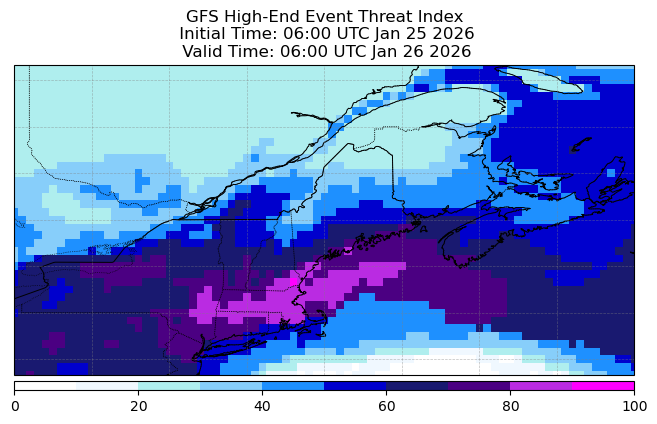

In [24]:
#plotting the high end event index threat
fig, ax6 = map()
plot6 = ax6.pcolormesh(lon, lat, PUI_high, transform = ccrs.PlateCarree(), cmap=colorbar_cmap, vmin = 0, vmax = 100)
axins = inset_axes(ax6, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax6.transAxes, borderpad = 0)
plt.colorbar(plot6, cax = axins, orientation = 'horizontal')
ax6.set_title(f"GFS High-End Event Threat Index\n Initial Time: {initial_time_high}\n Valid Time: {valid_time_high}")
plt.show()

### Plotting Low to Visualize

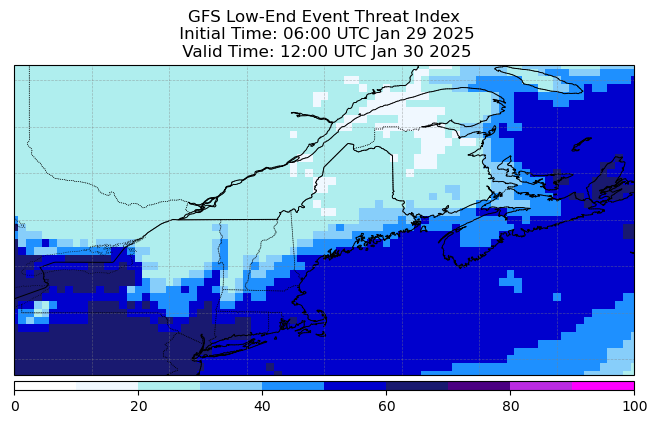

In [25]:
#plotting the low end event threat index
fig, ax7 = map()
plot7 = ax7.pcolormesh(lon, lat, PUI_low, transform = ccrs.PlateCarree(), cmap=colorbar_cmap, vmin = 0, vmax = 100)
axins = inset_axes(ax7, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax7.transAxes, borderpad = 0)
plt.colorbar(plot7, cax = axins, orientation = 'horizontal')
ax7.set_title(f"GFS Low-End Event Threat Index\n Initial Time: {initial_time_low}\n Valid Time: {valid_time_low}")
plt.show()

### Evaluating algoritm's performance: 

#### Did it produce reasonable values: 
Yes both of the plots produced reasonable values. For the high-end case on January 26, 2026, there was a large snow storm that produced a lot of snow accumulation and below freezing temperatures across the northeast. So, we expect skiing condintions to be very good. For the low-end case on January 29th, 2025, temperatures were abnormally warm for January, with no snow accummulation for most states, with rain recorded in many areas. So due to those factors, we expect skiing conditions to be poor.

Our algorithm did produce reasonables values because the high-end plot displayed values from 80-100 for most of the northeast, which clearly shows that there are better skiing conditions in the northeast. The low index plot has values across the northeast that are in the range from 10-60, which shows that skiing conditions are not ideal, especially for the northern most states in the northeast where most skiing resorts are located. We also used the SC-ASIS website to generate the temperatures and precip values/precip type for the state of new york (because it is in the middle of the northeast and has a high number of ski resorts) for the high end and low end dates. We used that to confirm that our low end date did indeed have high temperatures and rain, and our high end date had low temperatures and a high snowfall recorded.

#### Were there false alarms or missed threats?
No, we did not encounter any false alarms or missed threats. This is largely because our threat index puts 70% of the weighting for good skiing conditions on temperature and snowfall. The remaining 30% is weighted based off of cloud cover and wind. By making sure to prioritize temperature and snowfall, we ensured that, for example, simply having low cloud cover for one day wouldnt give high values for skiing conditions, there would also need to be a low temperature and high snowfall.

#### Did we need to revise the formula? If so, how?
No, we did not need to revise the formula because it works well and our high end and low end cases matched our expectations for the threat index. This is largely because of our variable weighting, which is explained above.

## 5. Automate Plot Generation

In [26]:
#Modifying code to produce a plot of our threat index for every time step in the model run

for t in range(len(ds.valid_time)):
    
    PUI, t2m_contribution, tcc_contribution, wind_contribution, tp_contribution = threat_index(ds, t)
    
    s_ds = ds.isel(valid_time=t)
    ds_ne = s_ds.sel(latitude=slice(50,40), longitude=slice(280,300))
    
    lat = ds_ne.latitude.values
    lon = ds_ne.longitude.values
    
    valid_time = datetime.strptime(str(s_ds.valid_time.values)[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the plot
    
    fig = plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    ax.set_extent([-80, -60, 40, 50])
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linestyle=':')
    
    #creating custom color range
    colorbar_range = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    colorbar_custom = [
        '#ffffff',       # white
        '#f0f8ff',       # aliceblue
        '#afeeee',       # paleturquoise
        '#87cefa',       # lightskyblue
        '#1e90ff',       # dodgerblue
        '#0000cd',       # mediumblue
        '#191970',       # midnightblue
        '#4b0082',       # indigo
        '#ba2be2',       # blueviolet
        '#ff00ff'        # magenta
    ]
    colorbar_cmap=mcolors.ListedColormap(colorbar_custom)
    
    plot = ax.pcolormesh(lon, lat, PUI, transform=ccrs.PlateCarree(),cmap=colorbar_cmap, vmin=0, vmax=100)
    
    axins = inset_axes(ax, width = "100%", height = "3%", loc = 'lower left', bbox_to_anchor = (0, -.05, 1, 1), bbox_transform=ax.transAxes, borderpad = 0)
    plt.colorbar(plot, cax = axins, orientation = 'horizontal')

    
    ax.set_title(f"GFS Threat Index\n Initial Time: {initial_time} \nValid Time: {valid_time}")
    

    #plt.savefig(f"threat_{t:03d}.png", dpi=150, bbox_inches='tight') #Saving each plot as a .png file with name
    
    plt.close()


# 6. Converting to Python Script

Completed as shown by the thret_index.py file. All png files are saved to the output folder. 